# 02 · Covariance des résidus et shrinkage Schäfer–Strimmer

**Bloc 2 · W37, notebook 2 sur 4.** MinT a besoin de $W = \operatorname{Var}(\mathbf y_h - \hat{\mathbf y}_h)$,
la covariance des erreurs de prévision de base. On l'estime à partir des résidus in-sample. L'estimateur empirique
est bruité, et il devient **singulier** dès que le nombre de séries dépasse le nombre d'observations. Le shrinkage
corrige ces deux problèmes.

| Étape | Objet | Code du package |
|---|---|---|
| 1 | Covariance empirique $W_1 = E'E/T$ | `shrunk_covariance(E).W1` |
| 2 | Corrélations $r_{ij}$ | — |
| 3 | λ de Schäfer–Strimmer, pas à pas | `schafer_strimmer_lambda(E)` |
| 4 | $W = \lambda\,\mathrm{diag}(W_1) + (1-\lambda)W_1$ | `shrunk_covariance(E).W` |
| 5 | Le mur `m > T` | `m_greater_than_T_demo(E)` |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.data import build_hierarchy, make_region_channel_data, train_test_split, to_wide
from w37_reconciliation.forecasting import fit_base_forecasts, residual_matrix

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)

In [2]:
# Mêmes données et mêmes prévisions que le notebook 01 (tout est déterministe, graine 0).
hier = build_hierarchy(make_region_channel_data(n=80, seed=0))
S, order = hier.S, hier.order
labels = viz.short(order)
train, test = train_test_split(hier.Y_df, h=8)
Y_hat, Y_fit = fit_base_forecasts(train, h=8)
E = residual_matrix(Y_fit, order)            # résidus one-step in-sample (T × m)
T, m = E.shape
print(f"T = {T} instants, m = {m} séries, nb = {S.shape[1]} feuilles")

T = 72 instants, m = 6 séries, nb = 4 feuilles


## 1. La covariance empirique $W_1 = E'E / T$

C'est l'estimateur du squelette du plan. Il est **non centré** : on suppose que les résidus one-step sont de
moyenne nulle, ce que le notebook 01 a vérifié. La diagonale contient la variance d'erreur de chaque série ; les
cases hors diagonale indiquent à quel point les erreurs de deux séries évoluent ensemble.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


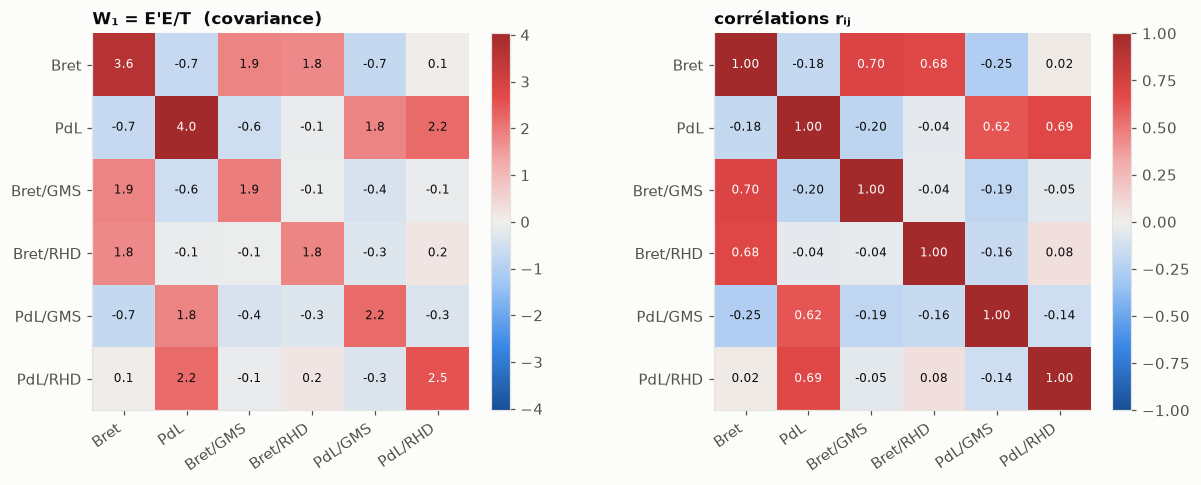

In [3]:
W1 = E.T @ E / T
d = np.sqrt(np.diag(W1))
R = W1 / np.outer(d, d)                       # corrélations
fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.3), layout="constrained")
viz.heatmap(axs[0], W1, labels, title="W₁ = E'E/T  (covariance)", fmt="{:.1f}", diverging=True)
viz.heatmap(axs[1], R, labels, title="corrélations rᵢⱼ", diverging=True, vmax=1)
plt.show()

**Lecture.**

- Chaque région est fortement corrélée à ses deux canaux. C'est attendu : l'erreur sur la région ressemble à la
  somme des erreurs sur ses canaux.
- Les feuilles sont générées **indépendamment**, donc leurs vraies corrélations valent 0. Les valeurs non nulles
  hors bloc sont **du bruit d'estimation**, et c'est ce bruit que le shrinkage va réduire.

## 2. Le λ de Schäfer–Strimmer, pas à pas

On rétrécit **les corrélations hors diagonale vers 0** (cible « D ») et on garde les variances intactes :

$$W = \lambda\,\mathrm{diag}(W_1) + (1-\lambda)\,W_1,
\qquad
\lambda^* = \frac{\sum_{i\ne j} \widehat{\operatorname{Var}}(r_{ij})}{\sum_{i\ne j} r_{ij}^2}$$

**Intuition.** Le numérateur mesure le **bruit** sur chaque corrélation estimée, le dénominateur leur **signal**
total. Si les corrélations sont bruitées par rapport à leur taille, λ → 1 et on se rapproche d'une matrice
diagonale. Si elles sont nettes, λ → 0 et on garde la covariance empirique.

Le calcul se fait sur les résidus standardisés $x_{ki} = e_{ki}/s_i$. On pose $w_{kij} = x_{ki}\,x_{kj}$, et :

$$r_{ij} = \overline{w}_{ij}, \qquad
\widehat{\operatorname{Var}}(r_{ij}) = \frac{T}{(T-1)^3} \sum_k \bigl(w_{kij} - \overline{w}_{ij}\bigr)^2$$

In [4]:
X = E / np.sqrt((E**2).mean(axis=0))          # (a) résidus standardisés
Wk = X[:, :, None] * X[:, None, :]             # (b) produits croisés à chaque instant : (T, m, m)
r = Wk.mean(axis=0)                            # (c) corrélations empiriques
var_r = T / (T - 1) ** 3 * ((Wk - r) ** 2).sum(axis=0)   # (d) variance de chaque corrélation
off = ~np.eye(m, dtype=bool)
num, den = var_r[off].sum(), (r[off] ** 2).sum()
lam = float(np.clip(num / den, 0, 1))
display(Markdown(f"Σ Var(rᵢⱼ) = **{num:.4f}**, Σ rᵢⱼ² = **{den:.4f}**, donc **λ = {lam:.6f}**"))

Σ Var(rᵢⱼ) = **0.4643**, Σ rᵢⱼ² = **4.0970**, donc **λ = 0.113325**

In [5]:
from w37_reconciliation.mint import schafer_strimmer_lambda, shrunk_covariance
print("fonction du package :", schafer_strimmer_lambda(E))
assert np.isclose(lam, schafer_strimmer_lambda(E))

fonction du package : 0.11332532101487676


Pour **chaque paire** (i, j), on compare le signal $r_{ij}^2$ au bruit $\widehat{\operatorname{Var}}(r_{ij})$.
Les paires région ↔ canal ont un fort signal. Les paires entre feuilles indépendantes sont dominées par le bruit :
ce sont elles qui justifient λ > 0.

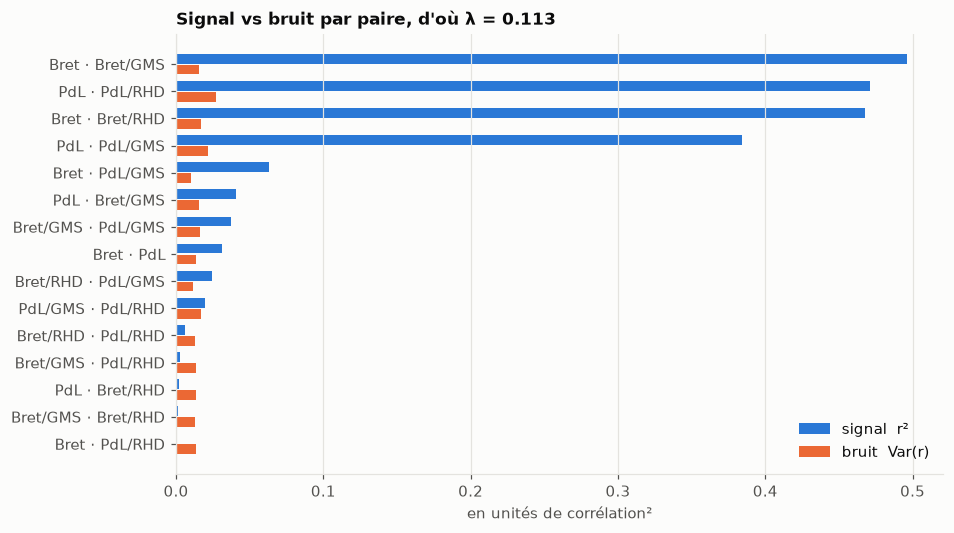

In [6]:
iu = np.triu_indices(m, 1)
pairs = pd.DataFrame({"paire": [f"{labels[i]} · {labels[j]}" for i, j in zip(*iu)],
                      "r²": r[iu] ** 2, "Var(r)": var_r[iu]}).sort_values("r²")
fig, ax = plt.subplots(figsize=(9, 5.2))
y = np.arange(len(pairs)); h = 0.4
ax.barh(y + h / 2, pairs["r²"], height=h - 0.04, color=viz.BLUE, label="signal  r²")
ax.barh(y - h / 2, pairs["Var(r)"], height=h - 0.04, color=viz.ORANGE, label="bruit  Var(r)")
ax.set_yticks(y, pairs["paire"]); ax.grid(axis="y", visible=False)
ax.set_xlabel("en unités de corrélation²")
ax.set_title(f"Signal vs bruit par paire, d'où λ = {lam:.3f}")
ax.legend(loc="lower right")
plt.show()

## 3. La covariance rétrécie $W$

Les variances (la diagonale) restent inchangées. Chaque covariance hors diagonale est multipliée par
$(1-\lambda) \approx 0{,}89$.

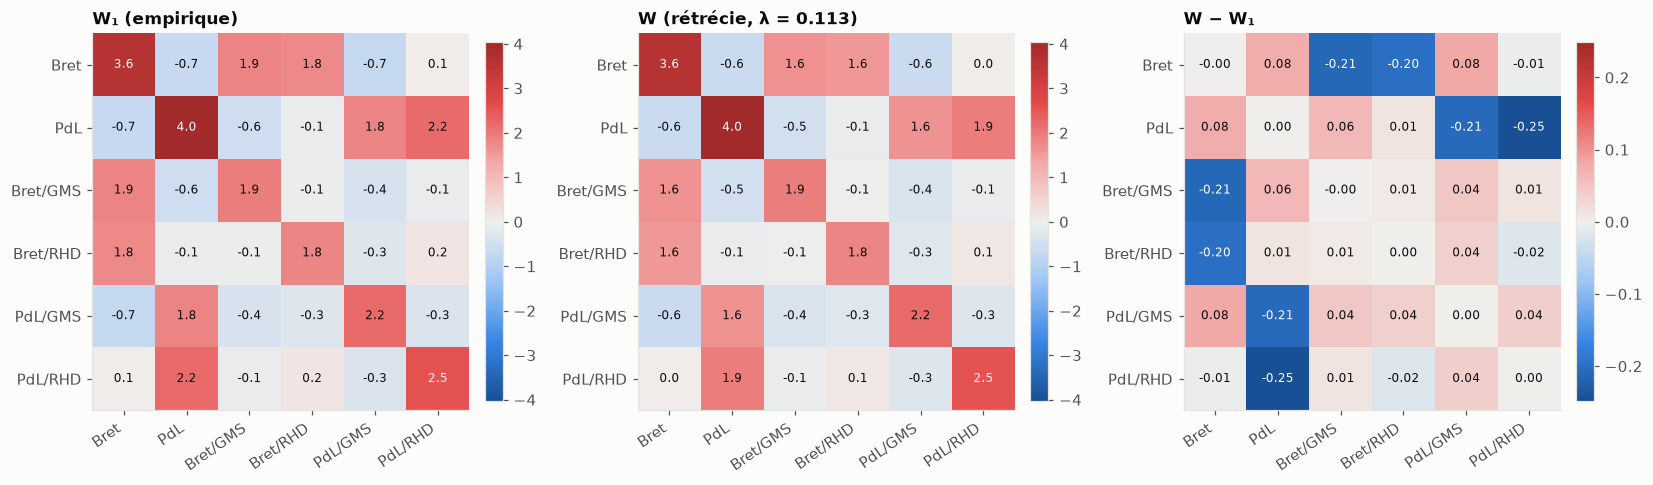

diagonale inchangée : True
conditionnement : W₁ = 27481.2, W = 23.2


In [7]:
cov = shrunk_covariance(E)                     # base « plan » : E'E/T
fig, axs = plt.subplots(1, 3, figsize=(15, 4.3), layout="constrained")
vmax = np.abs(cov.W1).max()
viz.heatmap(axs[0], cov.W1, labels, title="W₁ (empirique)", fmt="{:.1f}", diverging=True, vmax=vmax)
viz.heatmap(axs[1], cov.W, labels, title=f"W (rétrécie, λ = {cov.lam:.3f})", fmt="{:.1f}", diverging=True, vmax=vmax)
viz.heatmap(axs[2], cov.W - cov.W1, labels, title="W − W₁", fmt="{:.2f}", diverging=True)
plt.show()
print("diagonale inchangée :", np.allclose(np.diag(cov.W), np.diag(cov.W1)))
print(f"conditionnement : W₁ = {np.linalg.cond(cov.W1):.1f}, W = {cov.condition_number:.1f}")

## 4. Le mur `m > T` : le shrinkage est une condition d'existence

$W_1 = E'E/T$ est de rang au plus T. Avec moins d'observations que de séries, elle est **singulière** et ne peut
pas être inversée. MinT a pourtant besoin de $W^{-1}$.

Pour le voir, on refait l'estimation sur les **T′ premiers résidus seulement**, avec T′ allant de 2 à 72, et on
mesure le conditionnement (le rapport entre la plus grande et la plus petite valeur propre). Au-delà d'environ
1e12, l'inversion n'a plus de sens numérique.

C'est exactement la situation d'un client qui a 40 000 SKU et 3 ans d'historique hebdomadaire (T = 156).

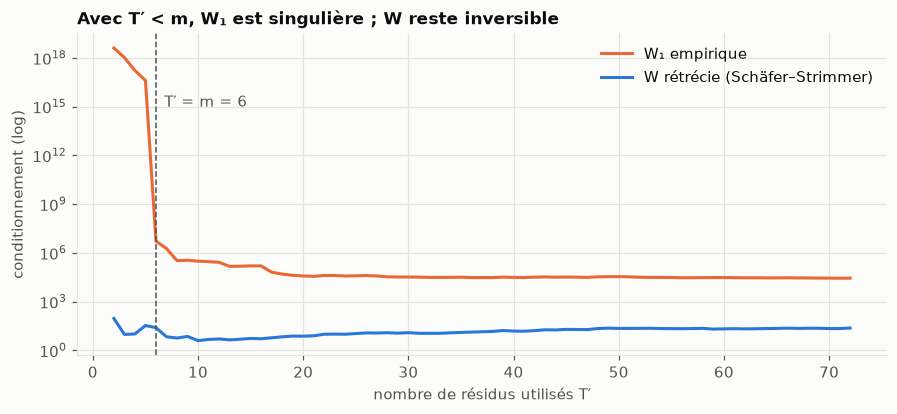

In [8]:
Ts = np.arange(2, T + 1)
conds = pd.DataFrame([{"T'": t, "cond(W₁)": np.linalg.cond(shrunk_covariance(E[:t]).W1),
                       "cond(W)": shrunk_covariance(E[:t]).condition_number,
                       "λ": shrunk_covariance(E[:t]).lam} for t in Ts]).set_index("T'")
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(conds.index, conds["cond(W₁)"], color=viz.ORANGE, label="W₁ empirique")
ax.plot(conds.index, conds["cond(W)"], color=viz.BLUE, label="W rétrécie (Schäfer–Strimmer)")
ax.axvline(m, color=viz.TEXT_2, ls="--", lw=1); ax.text(m + 0.8, 1e15, "T′ = m = 6", color=viz.TEXT_2)
ax.set_yscale("log"); ax.set_xlabel("nombre de résidus utilisés T′"); ax.set_ylabel("conditionnement (log)")
ax.set_title("Avec T′ < m, W₁ est singulière ; W reste inversible")
ax.legend()
plt.show()

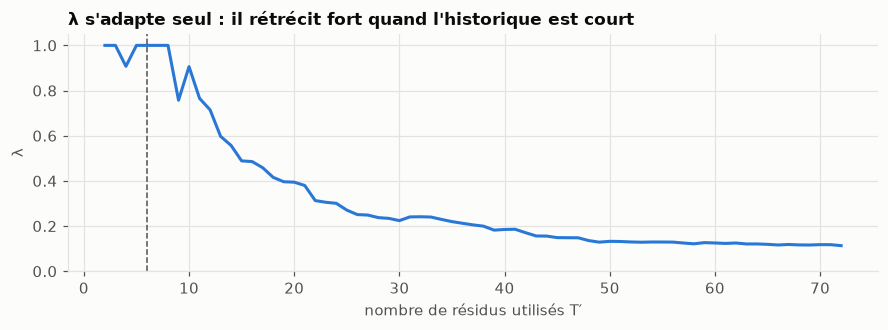

,cond(W₁),cond(W),λ
T',,,
3,1.0e+18,9.4,1.000
4,1.7e+17,10.1,0.907
5,4.0e+16,33.1,1.000
6,5.2e+06,24.7,1.000
8,3.3e+05,5.7,1.000
12,2.6e+05,5.0,0.715
24,3.7e+04,9.7,0.301
72,2.7e+04,23.2,0.113


In [9]:
fig, ax = plt.subplots(figsize=(9.5, 2.8))
ax.plot(conds.index, conds["λ"], color=viz.BLUE)
ax.axvline(m, color=viz.TEXT_2, ls="--", lw=1)
ax.set_ylim(0, 1.05); ax.set_xlabel("nombre de résidus utilisés T′"); ax.set_ylabel("λ")
ax.set_title("λ s'adapte seul : il rétrécit fort quand l'historique est court")
plt.show()
display(conds.loc[[3, 4, 5, 6, 8, 12, 24, 72]].style.format({"cond(W₁)": "{:.1e}", "cond(W)": "{:.1f}", "λ": "{:.3f}"}))

**Deux constats.**

1. Avec $T' < m$, le conditionnement de $W_1$ dépasse 1e16 : la matrice est numériquement singulière. Celui de
   $W$ reste sous 100.
2. **Même avec T = 72 ≫ m = 6, $W_1$ reste mal conditionnée (≈ 3e4).** Ce n'est pas un manque de données, c'est la
   structure : le résidu d'une région est presque la somme des résidus de ses canaux, donc les colonnes de E sont
   quasi colinéaires. Le shrinkage, en renforçant la diagonale, ramène le conditionnement à environ 23.

## À retenir

- $W_1$ empirique est bruitée : des corrélations qui devraient valoir 0 ne valent pas 0.
- Le λ de Schäfer–Strimmer se calcule **sans paramètre à régler**. Il compare le bruit des corrélations à leur
  signal, et vaut ici λ ≈ 0,113.
- Quand `m > T`, le shrinkage n'est pas un confort : sans lui, $W$ n'est pas inversible. **Avant de chiffrer une
  mission, demander le nombre de séries et la profondeur d'historique.**

→ Notebook **03** : avec $W$ en main, on construit $G$ et la projection $P$.